# Academic Paper Virality: An Agent-Based Model

> Computational Analysis of Social Complexity

**Prerequisites**
- ABM concepts
- Basic network analysis
- Data manipulation with pandas

**Outcomes**
- Build an ABM using real-world data
- Model citation dynamics in academic networks
- Analyze emergence of "viral" papers and sleeping beauties

**References**
- ArXiv Dataset: https://www.kaggle.com/datasets/Cornell-University/arxiv
- Citation Network Tools: https://github.com/mattbierbaum/arxiv-public-datasets

## Overview

- Academic papers spread through citation networks
- Some papers go "viral" quickly, others are "sleeping beauties" that gain citations years later
- We'll model how papers gain citations based on:
    - Author prestige
    - Topic trends
    - Network position
    - Quality/novelty

## Part 1: Data Collection & Exploration

### Setup and Dependencies

In [1]:
# Dependencies (numpy, pandas, networkx, mesa, matplotlib) are already installed
# via uv; see pyproject.toml. No package installation step is needed here.

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import mesa
import matplotlib.pyplot as plt

### Download Sample ArXiv Data

For this example, we'll work with a subset of ArXiv papers. In practice, you would download the full dataset from Kaggle.

In [3]:
# For demonstration, we'll create synthetic data that mimics ArXiv structure
# In practice, download from: https://www.kaggle.com/datasets/Cornell-University/arxiv


def create_sample_arxiv_data(n_papers=1000, n_authors=300, seed=6318):
    rng = np.random.default_rng(seed)

    # Create authors with varying prestige
    authors = pd.DataFrame({
        "author_id": np.arange(1, n_authors + 1),
        "name": [f"Author_{i}" for i in range(1, n_authors + 1)],
        "h_index": rng.integers(1, 51, n_authors),
        "institution_rank": rng.integers(1, 101, n_authors),
    })

    # Create papers
    papers = pd.DataFrame({
        "paper_id": np.arange(1, n_papers + 1),
        "title": [f"Paper_{i}" for i in range(1, n_papers + 1)],
        "year": rng.integers(2010, 2024, n_papers),
        "month": rng.integers(1, 13, n_papers),
        "category": rng.choice(["cs.AI", "cs.LG", "stat.ML", "physics", "math"], n_papers),
        "abstract_length": rng.integers(100, 501, n_papers),
        "n_authors": rng.integers(1, 6, n_papers),
        "lead_author_id": rng.integers(1, n_authors + 1, n_papers),
        "quality_score": rng.random(n_papers),  # Hidden variable representing paper quality
    })

    # Create citation network (papers cite older papers)
    years = papers["year"].to_numpy()
    citing, cited, cite_year = [], [], []
    for i in range(n_papers):
        paper_year = years[i]
        # Papers can only cite older papers
        older_papers = np.flatnonzero(years < paper_year)
        if len(older_papers) > 0:
            n_citations = min(int(rng.integers(0, 21)), len(older_papers))
            if n_citations > 0:
                chosen = rng.choice(older_papers, size=n_citations, replace=False)
                for c in chosen:
                    citing.append(papers.loc[i, "paper_id"])
                    cited.append(papers.loc[c, "paper_id"])
                    cite_year.append(int(paper_year) + int(rng.integers(0, 3)))

    citations = pd.DataFrame({
        "citing_paper": citing,
        "cited_paper": cited,
        "citation_year": cite_year,
    })

    return papers, authors, citations


papers_df, authors_df, citations_df = create_sample_arxiv_data()
print(f"Generated {len(papers_df)} papers, {len(authors_df)} authors, {len(citations_df)} citations")

Generated 1000 papers, 300 authors, 9032 citations


### Explore the Data

In [4]:
# Show sample of papers
papers_df.head()

,paper_id,title,year,month,category,abstract_length,n_authors,lead_author_id,quality_score
0,1,Paper_1,2015,2,cs.LG,154,2,93,0.332124
1,2,Paper_2,2023,7,math,475,2,247,0.191233
2,3,Paper_3,2019,6,physics,383,2,240,0.724146
3,4,Paper_4,2020,8,cs.AI,341,1,174,0.870293
4,5,Paper_5,2016,11,cs.LG,354,2,283,0.064693


In [5]:
# Citation statistics
citation_counts = citations_df.groupby("cited_paper").size().reset_index(name="n_citations")
citation_counts["n_citations"].describe()

count    853.000000
mean      10.588511
std        8.724162
min        1.000000
25%        4.000000
50%        8.000000
75%       15.000000
max       41.000000
Name: n_citations, dtype: float64

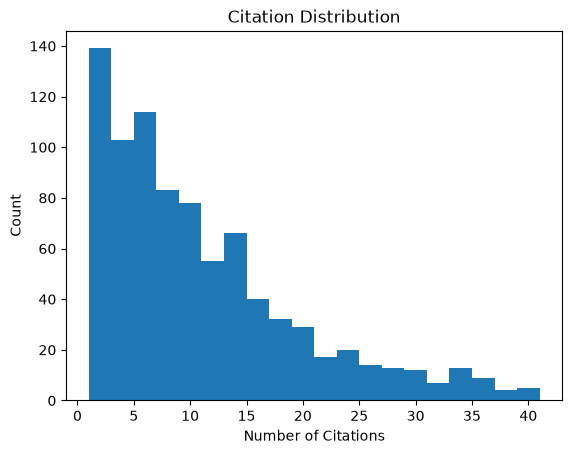

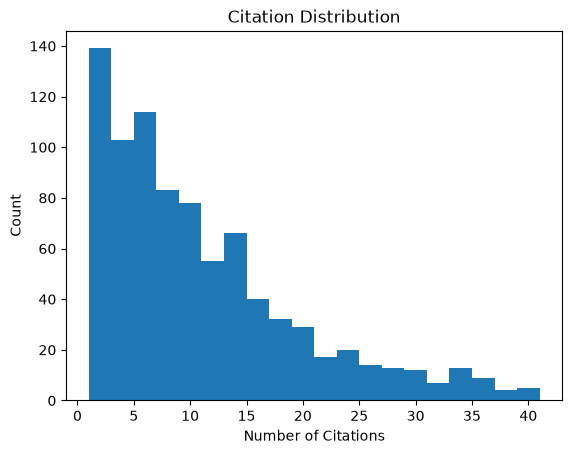

In [6]:
# Visualize citation distribution (classic power law)
fig, ax = plt.subplots()
ax.hist(citation_counts["n_citations"], bins=20)
ax.set_xlabel("Number of Citations")
ax.set_ylabel("Count")
ax.set_title("Citation Distribution")
fig

### Analyze Network Structure

In [7]:
# Build citation graph
def build_citation_graph(papers_df, citations_df):
    g = nx.DiGraph()
    g.add_nodes_from(papers_df["paper_id"])
    g.add_edges_from(zip(citations_df["citing_paper"], citations_df["cited_paper"]))
    return g


citation_graph = build_citation_graph(papers_df, citations_df)
avg_degree = np.mean([d for _, d in citation_graph.degree()])
print(f"Graph has {citation_graph.number_of_nodes()} nodes and {citation_graph.number_of_edges()} edges")
print(f"Average degree: {avg_degree:.2f}")

Graph has 1000 nodes and 9032 edges
Average degree: 18.06


## Part 2: Agent-Based Model Design

### Model Components

**Agents**: Research papers
- Properties: quality, author prestige, field, age, citation count
- Behavior: Papers get "read" by researchers who may cite them

**Environment**: Academic field with trending topics
- Topic hotness varies over time
- Conferences/journals provide visibility boosts

**Rules**:
1. Each time step, new papers are "published"
2. Researchers "read" papers based on:
   - Recent publications (recency bias)
   - High citation count (preferential attachment)
   - Author prestige
   - Topic match with current trends
3. Read papers get cited with probability based on quality

### Define Agent Structure

In [8]:
class Paper(mesa.Agent):
    def __init__(self, model, quality, author_prestige, field, publication_time):
        super().__init__(model)
        # Fixed properties
        self.quality = quality
        self.author_prestige = author_prestige
        self.field = field
        self.publication_time = publication_time

        # Dynamic properties
        self.citations = 0
        self.reads = 0  # Times the paper has been read
        self.age = 0

### Define Model Properties

In [9]:
class ModelProperties:
    def __init__(self, current_time, field_trends, n_researchers,
                 papers_per_researcher, citation_prob_base, new_papers_per_step):
        self.current_time = current_time
        self.field_trends = field_trends  # dict: field -> "hotness"
        self.n_researchers = n_researchers  # Number of researchers reading papers each time step
        self.papers_per_researcher = papers_per_researcher  # Papers read per researcher per time step
        self.citation_prob_base = citation_prob_base  # Base probability of citing a read paper
        self.new_papers_per_step = new_papers_per_step  # New papers published each time step

### Model Rules

In [10]:
def select_papers_to_read(papers, n, props, rng):
    if len(papers) <= n:
        return papers

    # Calculate selection weights
    weights = []
    for paper in papers:
        # Recency bias
        recency_weight = np.exp(-paper.age / 365.0)  # Decay over a year

        # Preferential attachment (rich get richer)
        citation_weight = np.log(2 + paper.citations)

        # Field trendiness
        trend_weight = props.field_trends.get(paper.field, 1.0)

        # Author prestige
        prestige_weight = paper.author_prestige

        weights.append(recency_weight * citation_weight * trend_weight * prestige_weight)

    # Weighted sampling without replacement
    weights = np.array(weights)
    probs = weights / weights.sum()
    indices = rng.choice(len(papers), size=n, replace=False, p=probs)
    return [papers[i] for i in indices]


def calculate_citation_probability(paper, props):
    # Base probability modified by paper quality and field trend
    base_prob = props.citation_prob_base
    quality_modifier = paper.quality
    trend_modifier = props.field_trends.get(paper.field, 1.0)

    return float(np.clip(base_prob * quality_modifier * trend_modifier, 0.0, 1.0))


def model_step(model):
    props = model.properties
    props.current_time += 1

    # Update field trends (random walk)
    for field in props.field_trends:
        props.field_trends[field] = float(
            np.clip(props.field_trends[field] + model.rng.normal() * 0.1, 0.1, 2.0)
        )

    # Age all papers
    for paper in model.agents:
        paper.age += 1

    # Researchers read and cite papers
    all_papers = list(model.agents)
    if len(all_papers) > 0:
        for _ in range(props.n_researchers):
            # Select papers to read (biased selection)
            papers_to_read = select_papers_to_read(
                all_papers, props.papers_per_researcher, props, model.rng
            )

            for paper in papers_to_read:
                paper.reads += 1

                # Decide whether to cite (based on quality and other factors)
                cite_prob = calculate_citation_probability(paper, props)
                if model.random.random() < cite_prob:
                    paper.citations += 1

    # Publish new papers
    for _ in range(props.new_papers_per_step):
        field = model.random.choice(list(props.field_trends.keys()))
        Paper(model, model.random.random(), model.random.random(), field, props.current_time)

    model.datacollector.collect(model)

### Initialize Model with Real Data

In [11]:
class PaperModel(mesa.Model):
    def __init__(self, papers_df, authors_df, n_researchers=100, papers_per_researcher=5, rng=None):
        super().__init__(rng=rng)

        # Create model properties
        fields = papers_df["category"].unique().tolist()
        field_trends = {f: 1.0 for f in fields}

        self.properties = ModelProperties(
            current_time=0,
            field_trends=field_trends,
            n_researchers=n_researchers,
            papers_per_researcher=papers_per_researcher,
            citation_prob_base=0.1,
            new_papers_per_step=10,
        )

        # Add initial papers from data (start with first 100 papers)
        authors_by_id = authors_df.set_index("author_id")
        for _, row in papers_df.head(min(100, len(papers_df))).iterrows():
            author = authors_by_id.loc[row["lead_author_id"]]
            prestige = author["h_index"] / 50.0  # Normalize to [0, 1]

            Paper(self, row["quality_score"], prestige, row["category"], 0)

        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "citations": "citations",
                "reads": "reads",
                "age": "age",
                "quality": "quality",
                "field": "field",
            }
        )
        self.datacollector.collect(self)

    def step(self):
        model_step(self)


model = PaperModel(papers_df, authors_df, rng=6318)
print(f"Model initialized with {len(model.agents)} papers")

Model initialized with 100 papers


## Part 3: Simulation & Analysis

### Run Simulation

In [12]:
# Run simulation
n_steps = 365  # Simulate one year
for _ in range(n_steps):
    model.step()

adf = model.datacollector.get_agent_vars_dataframe()

print(f"Simulation complete. Final model has {len(model.agents)} papers")

Simulation complete. Final model has 3750 papers


### Analyze Citation Dynamics

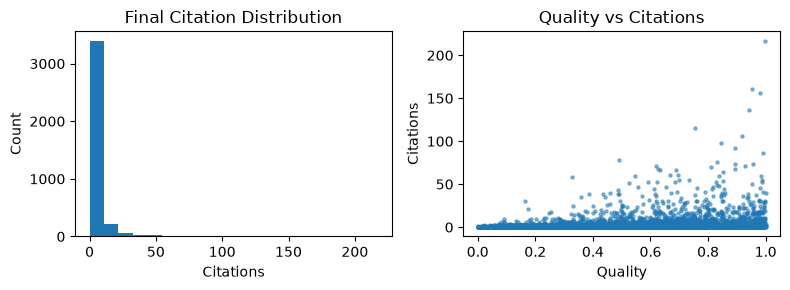

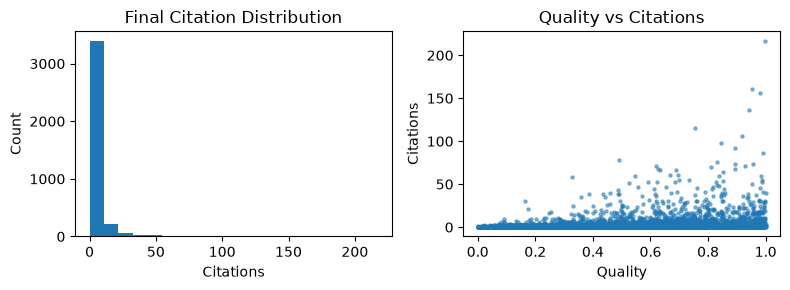

In [13]:
# Get final state
final_step = adf.index.get_level_values("Step").max()
final_data = adf.xs(final_step, level="Step")

# Citation distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# Histogram of citations
ax1.hist(final_data["citations"], bins=20)
ax1.set_xlabel("Citations")
ax1.set_ylabel("Count")
ax1.set_title("Final Citation Distribution")

# Quality vs Citations scatter
ax2.scatter(final_data["quality"], final_data["citations"], s=5, alpha=0.5)
ax2.set_xlabel("Quality")
ax2.set_ylabel("Citations")
ax2.set_title("Quality vs Citations")

fig.tight_layout()
fig

In [14]:
# Track citation growth over time
def analyze_citation_patterns(adf):
    # Group by paper ID first, then process each group
    velocities = {}

    for paper_id, group in adf.groupby(level="AgentID"):
        # Sort by time and get citations
        sorted_group = group.sort_index(level="Step")
        citations_over_time = sorted_group["citations"].to_numpy()

        if len(citations_over_time) > 1:
            velocities[paper_id] = np.diff(citations_over_time)

    return velocities


velocities = analyze_citation_patterns(adf)

# Find viral papers (high early velocity)
viral_papers = []
sleeping_beauties = []

for paper_id, vel in velocities.items():
    if len(vel) >= 10:
        early_velocity = vel[:10].mean()
        late_velocity = vel[-10:].mean()

        if early_velocity > 0.5:  # Threshold for "viral"
            viral_papers.append(paper_id)
        elif early_velocity < 0.1 and late_velocity > 0.3:  # Sleeping beauty pattern
            sleeping_beauties.append(paper_id)

print(f"Found {len(viral_papers)} viral papers")
print(f"Found {len(sleeping_beauties)} sleeping beauties")

Found 23 viral papers
Found 2 sleeping beauties


### Visualize Citation Trajectories

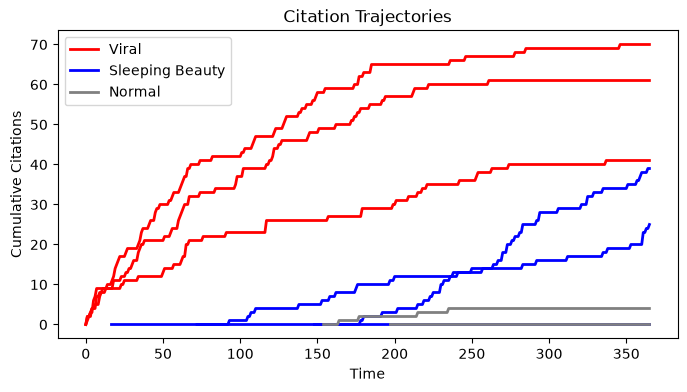

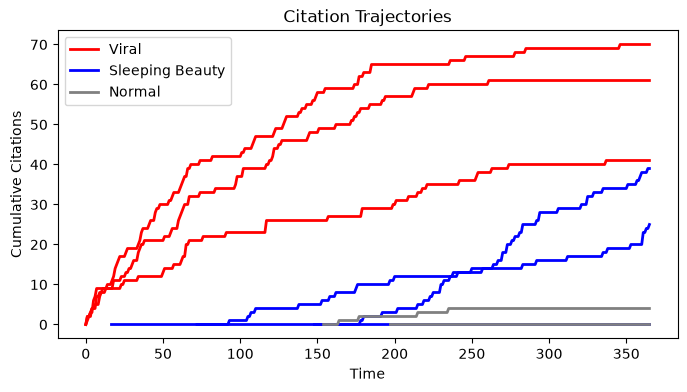

In [15]:
# Plot citation trajectories for different paper types
fig, ax = plt.subplots(figsize=(8, 4))

# Plot a sample of papers
all_ids = adf.index.get_level_values("AgentID").unique()
remaining_ids = [pid for pid in all_ids if pid not in viral_papers and pid not in sleeping_beauties]
n_remaining = min(3, len(remaining_ids))
random_sample = list(model.random.sample(remaining_ids, n_remaining)) if n_remaining > 0 else []

sample_papers = viral_papers[:3] + sleeping_beauties[:3] + random_sample
colors = ["red", "red", "red", "blue", "blue", "blue", "gray", "gray", "gray"]
labels = ["Viral", "", "", "Sleeping Beauty", "", "", "Normal", "", ""]

seen_labels = set()
for i, paper_id in enumerate(sample_papers):
    paper_data = adf.xs(paper_id, level="AgentID").sort_index(level="Step")

    if len(paper_data) > 0:
        label = labels[min(i, len(labels) - 1)]
        ax.plot(
            paper_data.index.get_level_values("Step"),
            paper_data["citations"],
            color=colors[min(i, len(colors) - 1)],
            label=label if label and label not in seen_labels else None,
            linewidth=2,
        )
        seen_labels.add(label)

ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Citations")
ax.set_title("Citation Trajectories")
ax.legend(loc="upper left")
fig

## Part 4: Parameter Calibration from Real Data

In [16]:
# Calibrate model parameters from real citation data
def calibrate_model(citations_df, papers_df, authors_df):
    # Calculate empirical citation rate
    citation_counts = citations_df.groupby("cited_paper").size()
    mean_citations = citation_counts.mean()

    # Calculate field popularity from data
    field_papers = papers_df.groupby("category").size()
    total_papers = field_papers.sum()
    field_popularity = (field_papers / total_papers).to_dict()

    # Calculate author prestige distribution
    merged = papers_df.merge(
        authors_df[["author_id", "h_index"]],
        left_on="lead_author_id", right_on="author_id", how="inner",
    )
    mean_prestige = (merged["h_index"] / 50.0).mean()

    print("Calibration Results:")
    print(f"  Mean citations per paper: {mean_citations:.2f}")
    print(f"  Mean author prestige: {mean_prestige:.3f}")
    print("  Field distribution:")
    for field, pop in field_popularity.items():
        print(f"    {field}: {pop * 100:.1f}%")

    return {
        "mean_citations": mean_citations,
        "field_trends": field_popularity,
        "mean_prestige": mean_prestige,
    }


calibration = calibrate_model(citations_df, papers_df, authors_df)

Calibration Results:
  Mean citations per paper: 10.59
  Mean author prestige: 0.499
  Field distribution:
    cs.AI: 21.8%
    cs.LG: 18.7%
    math: 19.4%
    physics: 20.8%
    stat.ML: 19.3%


## Exercises

1. **Network Effects**: Modify the model to include co-authorship networks. Papers by frequently collaborating authors should have higher visibility.

2. **Conference Boost**: Add "conference" events where papers in certain fields get temporary visibility boosts.

3. **Real Data**: Download the full ArXiv dataset from Kaggle and run the model with real papers. Compare simulated citation patterns to actual ones.

4. **Intervention Analysis**: What happens if we:
   - Increase open access (higher base read probability)?
   - Add social media promotion (viral boost for some papers)?
   - Implement better recommendation systems (quality-based selection)?

## Summary

- Built an ABM of academic paper citations using real data structure
- Observed emergence of power law citation distributions
- Identified viral papers and sleeping beauties
- Model can help understand:
    - How quality vs. marketing affects impact
    - Role of author prestige and networks
    - Effects of field trends on citation patterns